# Examples using the custom _NatureDataCube_ wrapper functions

**Author:** Bruno Marcos

**Created in:** June 5, 2026

**Last modified in:** June 22, 2026

In [1]:
# Load packages
pkgs <- c("rNDC", "dplyr")
pkgs |>
  lapply(FUN = library, character.only = TRUE) |>
  invisible() |>
  suppressPackageStartupMessages()

# Define parameters
mytoken <- Sys.getenv("NDC_TOKEN")
startdate <- "2026-04-21"
enddate <- "2026-05-07"

# Define output directory
tmp <- tempdir()
print(tmp)

There were 12 warnings (use warnings() to see them)


[1] "/tmp/RtmpqpjWrx"


## Importing and formatting custom regions of interest (RoI)

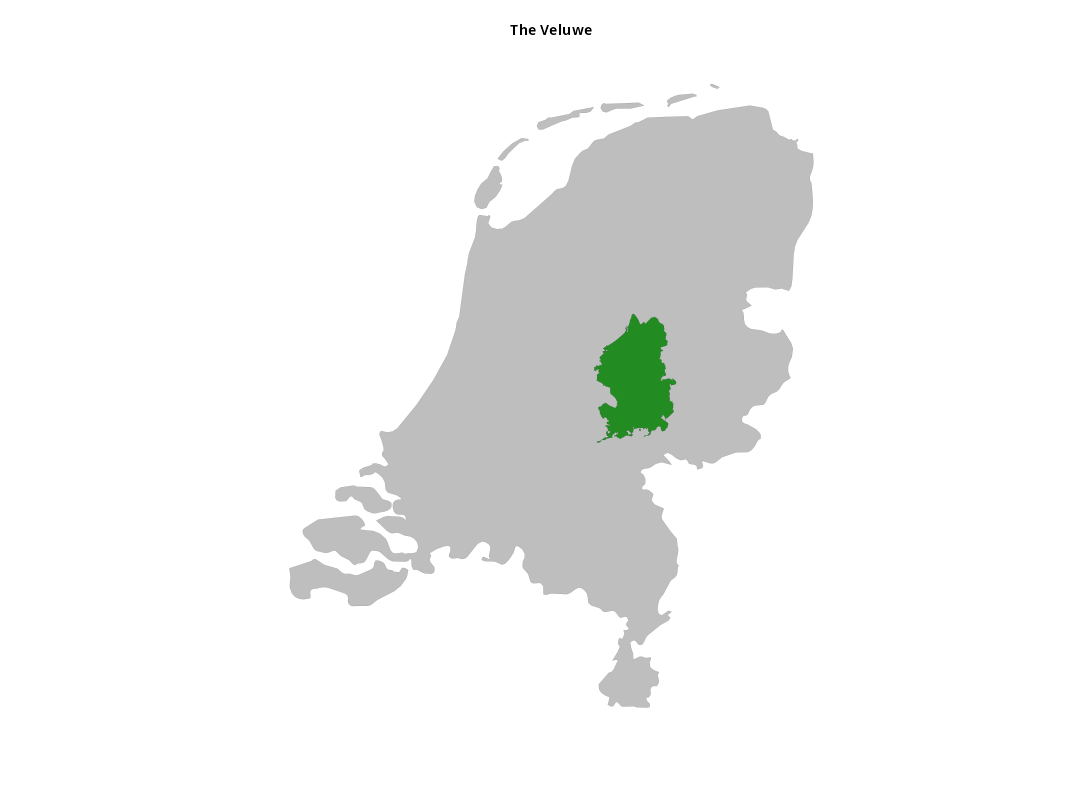

In [2]:
# Import boundaries 
nl <- system.file("extdata/nl.gpkg", package = "rNDC") |>
  ndc_roi()
veluwe <- system.file("extdata/veluwe.gpkg", package = "rNDC") |>
  ndc_roi()

# Visualize RoI
plot(nl, col = "grey", lwd = 0.1, main = "The Veluwe")
plot(veluwe, col = "forestgreen", lwd = 0.1, add = TRUE)

## Formatting temporal ranges

### Single date

In [3]:
ndc_trange(startdate)

[1] "2026-04-21T00:00:00Z"

### Closed temporal ranges

In [4]:
twindow <- ndc_trange(c(startdate, enddate))
twindow

[1] "2026-04-21T00:00:00Z/2026-05-07T00:00:00Z"

### Closed temporal ranges (with automatic ordering)

In [5]:
ndc_trange(c(enddate, startdate))

[1] "2026-04-21T00:00:00Z/2026-05-07T00:00:00Z"

### Open temporal ranges

In [6]:
ndc_trange(c(startdate, NA))

[1] "2026-04-21T00:00:00Z/.."

In [7]:
ndc_trange(c(NA, enddate))

[1] "../2026-05-07T00:00:00Z"

## Listing available datasets

### List of dataset names (_Collection IDs_)

In [14]:
datasets <- ndc_datasets()
print(datasets)

 [1] "ndvi-lter"      "ndvi-snl"       "lter"           "nh3"            "snl"           
 [6] "nox"            "soiltypes"      "rgb"            "nh3-snl"        "nox-lter"      
[11] "ntot"           "lgn"            "ndvi"           "nh3-lter"       "lgn-snl"       
[16] "nox-snl"        "ntot-lter"      "ntot-snl"       "lgn-lter"       "soiltypes-lter"
[21] "soiltypes-snl" 


### Total number of items for a single dataset

In [15]:
ndc_count(collection = "ndvi")

[1] 292

### Number of items of a single dataset matched with spatiotemporal contraints

In [16]:
ndc_count(collection = "ndvi",
          roi = veluwe,
          trange = twindow)

[1] 3

### Total number of items per dataset

In [17]:
ndc_datasets(total = TRUE)

       dataset_id  n_total
1       ndvi-lter     7489
2        ndvi-snl 35126884
3            lter       34
4             nh3        3
5             snl   264468
6             nox        3
7       soiltypes        1
8             rgb      291
9         nh3-snl   792000
10       nox-lter      102
11           ntot        3
12            lgn        1
13           ndvi      292
14       nh3-lter      102
15        lgn-snl   263994
16        nox-snl   792000
17      ntot-lter      102
18       ntot-snl   792541
19       lgn-lter       34
20 soiltypes-lter       34
21  soiltypes-snl   264468

### Number of matched items per dataset (spatial contraints only)

In [18]:
ndc_datasets(roi = veluwe)

       dataset_id n_matched
1       ndvi-lter      6254
2        ndvi-snl   3248027
3            lter        28
4             nh3         3
5             snl     13955
6             nox         3
7       soiltypes         1
8             rgb       291
9         nh3-snl     41859
10       nox-lter        84
11           ntot         3
12            lgn         1
13           ndvi       292
14       nh3-lter        84
15        lgn-snl     13953
16        nox-snl     41859
17      ntot-lter        84
18       ntot-snl     41859
19       lgn-lter        28
20 soiltypes-lter        28
21  soiltypes-snl     13953

### Complete table of available datasets for specific spatiotemporal constraints

In [19]:
ndc_datasets(roi = veluwe,
             trange = twindow,
             total = TRUE)

       dataset_id  n_total n_matched
1       ndvi-lter     7489       159
2        ndvi-snl 35126884     67926
3            lter       34        28
4             nh3        3         0
5             snl   264468     13955
6             nox        3         0
7       soiltypes        1         0
8             rgb      291         3
9         nh3-snl   792000         0
10       nox-lter      102         0
11           ntot        3         0
12            lgn        1         0
13           ndvi      292         3
14       nh3-lter      102         0
15        lgn-snl   263994         0
16        nox-snl   792000         0
17      ntot-lter      102         0
18       ntot-snl   792541         0
19       lgn-lter       34         0
20 soiltypes-lter       34         0
21  soiltypes-snl   264468         0

## Searching & listing items

### Search all items within a dataset

In [21]:
ndc_get(collection = "ndvi")

###STACItemCollection
- matched feature(s): 292
- features (100 item(s) / 192 not fetched):
  - gm-groenmonitor__ndvi_20260814
  - gm-groenmonitor__ndvi_20260812
  - gm-groenmonitor__ndvi_20260809
  - gm-groenmonitor__ndvi_20260804
  - gm-groenmonitor__ndvi_20260728
  - gm-groenmonitor__ndvi_20260725
  - gm-groenmonitor__ndvi_20260713
  - gm-groenmonitor__ndvi_20260625
  - gm-groenmonitor__ndvi_20260620
  - gm-groenmonitor__ndvi_20260528
  - ... with 90 more feature(s).
- assets: download, legend, thumbnail, wcs, wms
- item's fields: 
assets, bbox, collection, geometry, id, links, properties, stac_extensions, stac_version, type

### Search items of a dataset that match spatiotemporal constraints

In [ ]:
myquery <- ndc_get(collection = "ndvi",
                   roi = veluwe,
                   trange = twindow)
print(myquery)

###STACItemCollection
- matched feature(s): 3
- features (3 item(s) / 0 not fetched):
  - gm-groenmonitor__ndvi_20260501
  - gm-groenmonitor__ndvi_20260429
  - gm-groenmonitor__ndvi_20260421
- assets: download, legend, thumbnail, wcs, wms
- item's fields: 
assets, bbox, collection, geometry, id, links, properties, stac_extensions, stac_version, type

### Counting number of matched items using search results

In [23]:
ndc_count(myquery)

[1] 3

## Retrieving metadata

### Retrieving NDVI stats for LTER sites

In [29]:
ndvi <- ndc_get(collection = "ndvi-lter",
                roi = veluwe,
                mode = "sf",
                limit = 10000)
print(ndvi)

Simple feature collection with 6254 features and 9 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 5.689241 ymin: 51.99509 xmax: 5.936116 ymax: 52.37747
Geodetic CRS:  WGS 84
First 10 features:
    ndc_id source parcel_collection_id             datetime ndvi_std ndvi_mean
1  1264498   LTER                 lter 2026-05-28T00:00:00Z   0.1017    0.7258
2  1264497   LTER                 lter 2026-05-28T00:00:00Z   0.0945    0.7413
3  1264496   LTER                 lter 2026-05-28T00:00:00Z   0.1005    0.6894
4  1264495   LTER                 lter 2026-05-28T00:00:00Z   0.0503    0.7516
5  1264491   LTER                 lter 2026-05-28T00:00:00Z   0.1101    0.7023
6  1264490   LTER                 lter 2026-05-28T00:00:00Z   0.0428    0.8194
7  1264489   LTER                 lter 2026-05-28T00:00:00Z   0.0896    0.7558
8  1264488   LTER                 lter 2026-05-28T00:00:00Z   0.1259    0.6781
9  1264487   LTER                 lter 2026-05-28T00:00:00Z   0.0908 

### Temporally aggregating NDVI mean by patch ID

_Note:_ The "ndvi_mean" and "ndvi_std" fields obtained through the "ndvi-lter" Collection metadata contain **spatially** aggregated values (i.e. from multiple pixels).

The following aggregates NDVI (spatial) mean values to only one value for each polygon.

In [30]:
ndvi |>
  summarize(NDVI_mean = mean(ndvi_mean, na.rm = TRUE),
            NDVI_sd = sd(ndvi_mean, na.rm = TRUE),
            NDVI_min = min(ndvi_mean, na.rm = TRUE),
            NDVI_max = max(ndvi_mean, na.rm = TRUE),
            across(geometry, st_union), # Only needed if `ndvi` is an `sf` object
            .by = ndc_id)

Simple feature collection with 28 features and 5 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 5.689241 ymin: 51.99509 xmax: 5.936116 ymax: 52.37747
Geodetic CRS:  WGS 84
First 10 features:
    ndc_id NDVI_mean    NDVI_sd NDVI_min NDVI_max                       geometry
1  1264498 0.6933064 0.05444649   0.5380   0.8203 POLYGON ((5.897389 52.37651...
2  1264497 0.7000205 0.05685869   0.5331   0.8193 POLYGON ((5.895003 52.3746,...
3  1264496 0.6930074 0.06722887   0.4657   0.8194 POLYGON ((5.891448 52.37194...
4  1264495 0.7050507 0.06207008   0.5340   0.8320 POLYGON ((5.888749 52.36961...
5  1264491 0.6932902 0.06271021   0.4418   0.8357 POLYGON ((5.886106 52.36824...
6  1264490 0.7355528 0.07812423   0.5602   0.8707 POLYGON ((5.852229 52.36794...
7  1264489 0.7344535 0.06498385   0.5790   0.8644 POLYGON ((5.853585 52.36701...
8  1264488 0.6805888 0.06751890   0.4086   0.8197 POLYGON ((5.885192 52.36666...
9  1264487 0.7564150 0.06211960   0.5886   0.9130 POLYGON 

The following aggregates NDVI (spatial) mean values to one value **per year**, for each polygon.

In [31]:
ndvi |>
  mutate(year = substr(observation_date, 1,4)) |>
  summarize(NDVI_mean = mean(ndvi_mean, na.rm = TRUE),
            NDVI_sd = sd(ndvi_mean, na.rm = TRUE),
            NDVI_min = min(ndvi_mean, na.rm = TRUE),
            NDVI_max = max(ndvi_mean, na.rm = TRUE),
            across(geometry, st_union), # Only needed if `ndvi` is an `sf` object
            .by = c(ndc_id, year))

Simple feature collection with 224 features and 6 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 5.689241 ymin: 51.99509 xmax: 5.936116 ymax: 52.37747
Geodetic CRS:  WGS 84
First 10 features:
    ndc_id year NDVI_mean    NDVI_sd NDVI_min NDVI_max                       geometry
1  1264498 2026 0.6905722 0.04290449   0.5991   0.8086 POLYGON ((5.897389 52.37651...
2  1264497 2026 0.6956824 0.03216757   0.6105   0.7413 POLYGON ((5.895003 52.3746,...
3  1264496 2026 0.6235765 0.05392538   0.4657   0.6971 POLYGON ((5.891448 52.37194...
4  1264495 2026 0.7023875 0.03748301   0.6061   0.7652 POLYGON ((5.888749 52.36961...
5  1264491 2026 0.6508563 0.03186243   0.5728   0.7117 POLYGON ((5.886106 52.36824...
6  1264490 2026 0.6928500 0.06151865   0.5895   0.8194 POLYGON ((5.852229 52.36794...
7  1264489 2026 0.6988250 0.04370897   0.6090   0.7608 POLYGON ((5.853585 52.36701...
8  1264488 2026 0.6219813 0.03357081   0.5481   0.6899 POLYGON ((5.885192 52.36666...
9  1264487 2